In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [4]:
df = pd.read_csv('mnist_train.csv')
df

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [10]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


In [11]:
#pre process

x_train = df.drop('label', axis = 1).values
y_train = df['label'].values

x_test = df.drop('label', axis = 1).values
y_test = df['label'].values

In [12]:
# to get all values between 0 to 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [14]:
#to structure each row(img) as an image

x_train_img = x_train.reshape(-1,28,28)
x_test_img = x_test.reshape(-1,28,28)

x_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [18]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

y_train

array([5, 0, 4, ..., 5, 6, 8])

In [19]:
perc = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

In [21]:
perc.compile(optimizer = 'sgd' , loss='categorical_crossentropy' , metrics=['accuracy'])

In [24]:
history = perc.fit(x_train_img , y_train_cat ,
                   epochs = 10,
                   batch_size = 32,
                   validation_data = (x_test_img , y_test_cat),
                   verbose = 1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8112 - loss: 0.7873 - val_accuracy: 0.8714 - val_loss: 0.5057
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8792 - loss: 0.4579 - val_accuracy: 0.8868 - val_loss: 0.4223
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8904 - loss: 0.4045 - val_accuracy: 0.8940 - val_loss: 0.3876
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8965 - loss: 0.3777 - val_accuracy: 0.8998 - val_loss: 0.3672
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9005 - loss: 0.3608 - val_accuracy: 0.9021 - val_loss: 0.3530
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9031 - loss: 0.3489 - val_accuracy: 0.9045 - val_loss: 0.3426
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9050 - loss: 0.3397 - val_accuracy: 0.9068 - val_loss: 0.3351
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9072 - loss: 0.3326 -

In [28]:
acc_perc = perc.evaluate(x_test_img,y_test_cat,verbose = 0)[1]
acc_perc

0.9112499952316284

In [29]:
#using ANN

ann = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128 , activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(10, activation = 'softmax')
])

In [31]:
ann.compile(optimizer = 'adam',
            loss = 'categorical_crossentropy',
            metrics = ['accuracy'])

In [32]:
history_ann = ann.fit(x_train_img , y_train_cat,
                      epochs = 10,
                      batch_size = 32,
                      validation_data = (x_test_img , y_test_cat),
                      verbose = 1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9283 - loss: 0.2418 - val_accuracy: 0.9668 - val_loss: 0.1124
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9690 - loss: 0.1011 - val_accuracy: 0.9805 - val_loss: 0.0664
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9777 - loss: 0.0720 - val_accuracy: 0.9840 - val_loss: 0.0487
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9830 - loss: 0.0535 - val_accuracy: 0.9863 - val_loss: 0.0415
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.9839 - val_loss: 0.0491
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9889 - loss: 0.0338 - val_accuracy: 0.9935 - val_loss: 0.0216
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9909 - loss: 0.0277 - val_accuracy: 0.9927 - val_loss: 0.0230
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9914 - loss: 0

In [33]:
ann_acc = ann.evaluate(x_test_img , y_test_cat , verbose = 0)[1]
ann_acc

0.9954500198364258

In [34]:
x_train_cnn = x_train_img.reshape(-1,28,28,1)
x_test_cnn = x_test_img.reshape(-1,28,28,1)

In [44]:
cnn = Sequential([
    Conv2D(32 , kernel_size = (3,3) , activation = 'relu' , input_shape = (28,28,1)),
    MaxPooling2D(pool_size = (2,2)),
    Conv2D(64 , kernel_size = (3,3) , activation = 'relu'),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(128 , activation = 'relu'),
    Dropout(0.5),
    Dense(10 , activation = 'softmax')


])

In [45]:
cnn.compile(optimizer = 'adam',
            loss = 'categorical_crossentropy',
            metrics = ['accuracy'])

In [46]:
history_cnn = cnn.fit(x_train_cnn , y_train_cat,
                      epochs = 5 ,
                      batch_size = 32,
                      validation_data = (x_test_cnn , y_test_cat),
                      verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - accuracy: 0.9341 - loss: 0.2154 - val_accuracy: 0.9841 - val_loss: 0.0511
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 41ms/step - accuracy: 0.9760 - loss: 0.0826 - val_accuracy: 0.9907 - val_loss: 0.0301
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9821 - loss: 0.0607 - val_accuracy: 0.9928 - val_loss: 0.0231
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9857 - loss: 0.0481 - val_accuracy: 0.9931 - val_loss: 0.0206
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.9881 - loss: 0.0403 - val_accuracy: 0.9961 - val_loss: 0.0130


In [49]:
acc_cnn = cnn.evaluate(x_test_cnn , y_test_cat , verbose = 0)[1]
acc_cnn

0.9961333274841309

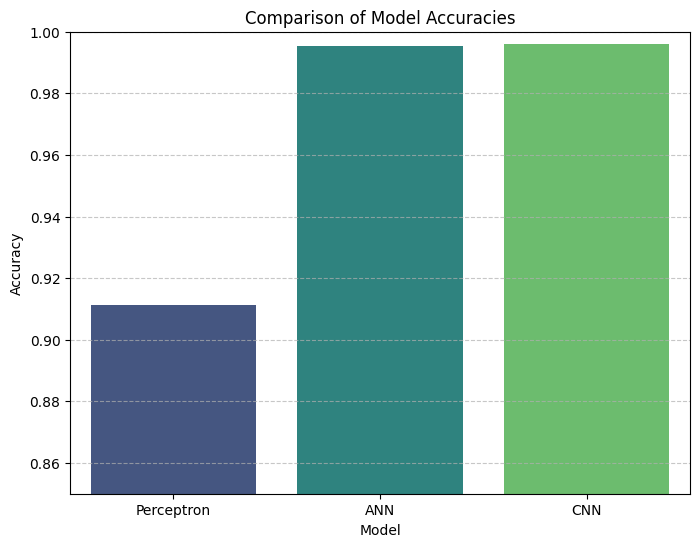

In [58]:
model_accuracies = pd.DataFrame({
    'Model': ['Perceptron', 'ANN', 'CNN'],
    'Accuracy': [acc_perc, ann_acc, acc_cnn]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0) # Adjusted y-axis limit to better visualize differences between high-performing models
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()